Pada tahap pelabelan data, penelitian ini menggunakan pendekatan automatic labeling dengan memanfaatkan model pretrained IndoRoBERTa, yaitu model bahasa berbasis transformer yang telah dilatih pada korpus teks bahasa Indonesia. Model ini digunakan untuk mengklasifikasikan setiap ulasan ke dalam tiga kategori sentimen, yaitu positif, negatif, dan netral, berdasarkan pemahaman konteks kalimat secara mendalam. Penggunaan model pretrained memungkinkan proses pelabelan dilakukan secara efisien dan konsisten tanpa anotasi manual, sekaligus memanfaatkan kemampuan representasi bahasa yang lebih baik dibandingkan metode konvensional. Dengan demikian, hasil pelabelan diharapkan cukup akurat untuk digunakan pada tahap pemodelan selanjutnya.

# Import Library & Dependencies

In [ ]:
!pip install transformers torch pandas tqdm

In [ ]:
import pandas as pd
import re
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# Gunakan GPU jika tersedia
device = 0 if torch.cuda.is_available() else -1
print(f"Menggunakan perangkat: {'GPU' if device == 0 else 'CPU'}")

Menggunakan perangkat: GPU


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def clean_text(text):
    text = str(text) if text is not None else ""
    # Menghapus karakter newline dan tab
    text = text.replace('\n', ' ').replace('\t', ' ')
    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text)
    # Menghapus spasi di awal dan akhir
    text = text.strip()
    return text

# Load Data & Pre-processing

In [ ]:
# Membaca file hasil scraping OVO sebelumnya
df = pd.read_csv("ulasan_raw_ovo.csv")

print(f"Total data: {len(df)}")

# Menjalankan fungsi pembersihan
df['content_clean'] = df['content'].apply(clean_text)

# Menghapus baris yang kosong jika ada
df = df[df['content_clean'] != ""].reset_index(drop=True)

Total data: 20000


In [ ]:
df.head()

,reviewId,content,content_clean
0,a4e17d51-263a-4fe6-a400-1e4e97ab3e9f,"Tolong saldo driver saya selesaikan prosesnya,...","Tolong saldo driver saya selesaikan prosesnya,..."
1,572d520d-c61c-47cf-80b7-47293b9761dd,sering pembaruan gak malah bagus malah sering ...,sering pembaruan gak malah bagus malah sering ...
2,138520c3-6f8d-41c5-a11d-1a2f234a10f6,"parah ini ovo, Top up saldo grab dari tadi mas...","parah ini ovo, Top up saldo grab dari tadi mas..."
3,28d45f83-7667-436a-8947-4b19d275be35,sering gangguan yg menyebabkan kerugian bagi k...,sering gangguan yg menyebabkan kerugian bagi k...
4,590d340a-a226-4cc2-b98c-0d81e0d24322,Ini aplikasi gimana sih 2x top up Saldo Pengem...,Ini aplikasi gimana sih 2x top up Saldo Pengem...


# Data Labelling

In [ ]:
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

print(f"Memuat Model & Tokenizer: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Membuat pipeline dengan fitur truncation otomatis
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device,
    truncation=True,
    padding=True,
    max_length=512
)

Memuat Model & Tokenizer: w11wo/indonesian-roberta-base-sentiment-classifier...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_labels_batched(texts, batch_size=32):
    results = []
    # Menggunakan tqdm untuk melihat progres 20.000 data
    for i in tqdm(range(0, len(texts), batch_size), desc="Proses Pelabelan"):
        batch = texts[i:i+batch_size]
        outputs = sentiment_pipe(batch)
        results.extend([out['label'] for out in outputs])
    return results

# Menjalankan pelabelan
df['roberta_label'] = get_labels_batched(df['content_clean'].tolist())

# Mapping label ke format Bahasa Indonesia
label_map = {
    'positive': 'Positif',
    'neutral': 'Netral',
    'negative': 'Negatif'
}
df['label_final'] = df['roberta_label'].map(label_map)

Proses Pelabelan:   0%|          | 0/625 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


/tmp/ipykernel_4728/276193017.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


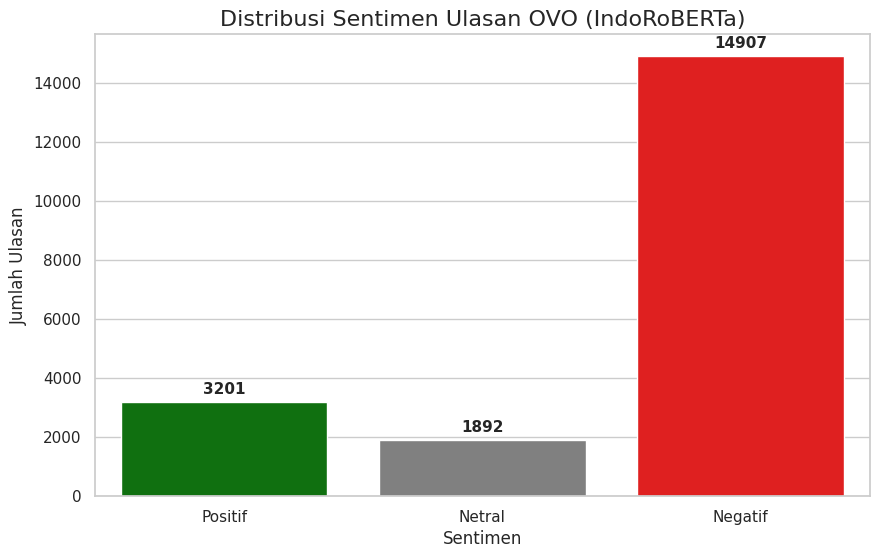

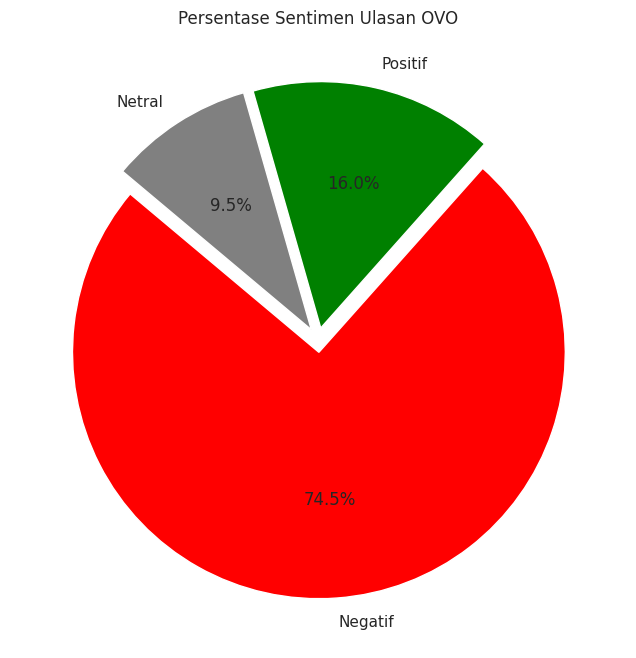

In [ ]:
# 1. Mengatur gaya visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Membuat Bar Plot untuk Distribusi Label
ax = sns.countplot(
    x='label_final',
    data=df,
    palette={'Positif': 'green', 'Netral': 'gray', 'Negatif': 'red'},
    order=['Positif', 'Netral', 'Negatif']
)

# 3. Menambahkan Judul dan Label
plt.title('Distribusi Sentimen Ulasan OVO (IndoRoBERTa)', fontsize=16)
plt.xlabel('Sentimen', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

# 4. Menambahkan Label Angka di Atas Bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11,
                fontweight='bold')

plt.show()

# 5. Opsional: Pie Chart untuk melihat persentase
plt.figure(figsize=(8, 8))
df['label_final'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['red', 'green', 'gray'], # Urutan mengikuti value_counts()
    startangle=140,
    explode=(0.05, 0.05, 0.05)
)
plt.title('Persentase Sentimen Ulasan OVO')
plt.ylabel('') # Menghapus label y agar lebih bersih
plt.show()

# Simpan Hasil

In [ ]:
# Menyimpan kolom yang diperlukan untuk tahap Machine Learning
output_file = "ulasan_ovo_labeled_final.csv"
df[['reviewId', 'content', 'label_final']].to_csv(output_file, index=False)

print("\n=== Ringkasan Pelabelan ===")
print(df['label_final'].value_counts())
print(f"\nSelesai! File '{output_file}' siap digunakan.")

# Tampilkan beberapa contoh hasil
df[['content', 'label_final']].sample(5)


=== Ringkasan Pelabelan ===
label_final
Negatif    14907
Positif     3201
Netral      1892
Name: count, dtype: int64

Selesai! File 'ulasan_ovo_labeled_final.csv' siap digunakan.


,content,label_final
371,apasih masuk ke ke ovo susah banget gangguan M...,Negatif
13200,transfer ke bank tidak ada promo gratis sepert...,Negatif
19465,bintang 1..saya isi saldo grab saldo nya sudah...,Negatif
11540,aplikasi tolol daftar keblokir²gajelas,Negatif
5620,mudah dn sangat mbntu saya trmksh ovo smnga tt...,Positif
